In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np
import math
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
LR_PRETRAIN = 1e-4 #modify these hyperparams?
LR_FINETUNE = 1e-5
EPOCHS_PRETRAIN = 20
EPOCHS_FINETUNE = 10
MASK_PROB = 0.15
H5_PATH = "drive/MyDrive/Exoplanet Detection/tess_lightcurves_unk.h5"
H5_LABELED = "drive/MyDrive/Exoplanet Detection/tess_lightcurves_not_unk.h5"
torch.manual_seed(13)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Create Dataset for Unknown Data

In [ ]:
#modified dataset to include masking for reconstruction
class TessDataset(Dataset):
    def __init__(self, h5_path, mask_prob=0.15, is_masked = False, is_labeled = True):
        """
        Loads unlabeled data and prepares it for Masked Language Modeling (BERT-style).
        """
        self.mask_prob = mask_prob
        self.f = h5py.File(h5_path, "r")
        self.global_flux = self.f["global_flux_view_fluxnorm"]
        self.global_centr = self.f["global_centr_view"]
        self.local_flux   = self.f["local_flux_view_fluxnorm"]
        self.local_centr  = self.f["local_centr_view"]
        self.N = self.global_flux.shape[0]
        self.is_masked = is_masked
        self.is_labeled = is_labeled
        if(self.is_labeled):
          self.labels = self.f["label"]

    def __len__(self):
        return self.N

    #apply masking to light curve in random fashion
    def apply_mask(self, flux):

        L = flux.shape[0]
        # Create boolean mask
        mask = torch.rand(L) < self.mask_prob

        masked_flux = flux.clone()
        masked_flux[mask] = 0.0

        return masked_flux, mask.float()

    def __getitem__(self, idx):
        if(self.is_masked):
          # Load flux and centroid data
          g_flux_orig = torch.tensor(self.global_flux[idx], dtype=torch.float32)
          g_cent = torch.tensor(self.global_centr[idx], dtype=torch.float32)
          l_flux_orig = torch.tensor(self.local_flux[idx], dtype=torch.float32)
          l_cent = torch.tensor(self.local_centr[idx], dtype=torch.float32)

          # Apply masking
          g_flux_masked, g_mask = self.apply_mask(g_flux_orig)
          l_flux_masked, l_mask = self.apply_mask(l_flux_orig)

          return {
              "global_flux_in": g_flux_masked,
              "global_flux_gt": g_flux_orig,
              "global_mask":    g_mask,         # Mask locs
              "global_cent":    g_cent,

              "local_flux_in":  l_flux_masked,
              "local_flux_gt":  l_flux_orig,
              "local_mask":     l_mask,
              "local_cent":     l_cent
          }
        else:
            return {
            "global_flux": torch.tensor(self.global_flux[idx], dtype=torch.float32),
            "global_cent": torch.tensor(self.global_centr[idx], dtype=torch.float32),
            "local_flux":  torch.tensor(self.local_flux[idx], dtype=torch.float32),
            "local_cent":  torch.tensor(self.local_centr[idx], dtype=torch.float32)
            }, torch.tensor(self.labels[idx], dtype=torch.long)

## Transformer Architecture

In [ ]:
#same as vanilla transformer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#same as vanilla transformer
class ConvEmbedding(nn.Module):
    def __init__(self, in_channels=2, hidden=32, d_model=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, hidden, kernel_size=5, padding=2),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
            nn.GELU()
        )
        self.proj = nn.Conv1d(hidden, d_model, kernel_size=1)

    def forward(self, x):
        h = self.conv(x)
        h = self.proj(h)
        return h.transpose(1, 2)


#learning reconstruction representations
class ExoBERT(nn.Module):

    def __init__(self, d_model=128, heads=8, ff=256, layers=2):
        super().__init__()

        self.d_model = d_model

        #local
        self.local_conv = ConvEmbedding(in_channels=2, d_model=d_model)
        self.local_pos  = PositionalEncoding(d_model)
        self.local_enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=heads, dim_feedforward=ff, batch_first=True, activation='gelu')
        self.local_transformer = nn.TransformerEncoder(self.local_enc_layer, num_layers=layers)

        # Reconstruction Head
        self.local_head = nn.Linear(d_model, 1)

        #global
        self.global_conv = ConvEmbedding(in_channels=2, d_model=d_model)
        self.global_pos  = PositionalEncoding(d_model)
        self.global_enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=heads, dim_feedforward=ff, batch_first=True, activation='gelu')
        self.global_transformer = nn.TransformerEncoder(self.global_enc_layer, num_layers=layers)
        # Reconstruction Head
        self.global_head = nn.Linear(d_model, 1)

        self.pre_ln = nn.LayerNorm(d_model)

    def process_stream(self, flux, cent, conv, pos, transformer, head):
        #embed
        x = torch.stack([flux, cent], dim=1)
        h = conv(x)
        h = pos(h)
        h = self.pre_ln(h)

        #encode
        h_seq = transformer(h) # (B, L, D)

        #project to flux dims
        recon = head(h_seq).squeeze(-1)
        return recon

    def forward(self, batch):
        #reconstruct local view
        l_recon = self.process_stream(
            batch["local_flux_in"], batch["local_cent"],
            self.local_conv, self.local_pos, self.local_transformer, self.local_head
        )

        #reconstruct global view
        g_recon = self.process_stream(
            batch["global_flux_in"], batch["global_cent"],
            self.global_conv, self.global_pos, self.global_transformer, self.global_head
        )

        return l_recon, g_recon

In [ ]:
class ExoClassifier(nn.Module):

    def __init__(self, pre_trained_bert, num_classes=2):
        super().__init__()

        #use encoder weights
        self.local_conv = pre_trained_bert.local_conv
        self.local_pos = pre_trained_bert.local_pos
        self.local_transformer = pre_trained_bert.local_transformer

        self.global_conv = pre_trained_bert.global_conv
        self.global_pos = pre_trained_bert.global_pos
        self.global_transformer = pre_trained_bert.global_transformer

        self.pre_ln = pre_trained_bert.pre_ln

        #classify instead of reconstruct
        d_model = pre_trained_bert.d_model
        self.head = nn.Sequential(
            nn.Linear(2 * d_model, d_model),
            nn.ReLU(),
            #nn.Dropout(0.2),
            nn.Linear(d_model, num_classes)
        )

    def freeze_encoder(self):
        #freeze all weights except for head
        modules_to_freeze = [
            self.local_conv, self.local_pos, self.local_transformer,
            self.global_conv, self.global_pos, self.global_transformer,
            self.pre_ln
        ]
        for module in modules_to_freeze:
            for param in module.parameters():
                param.requires_grad = False

    def unfreeze_encoder(self):
        for param in self.parameters():
            param.requires_grad = True

    def encode_view(self, flux, cent, conv, pos, transformer):
        x = torch.stack([flux, cent], dim=1)
        h = conv(x)
        h = self.pre_ln(h)
        h = pos(h)
        h = transformer(h)

        #max pooling
        pooled, _ = torch.max(h, dim=1)
        return pooled

    def forward(self, batch):
        h_local = self.encode_view(
            batch["local_flux"], batch["local_cent"],
            self.local_conv, self.local_pos, self.local_transformer
        )
        h_global = self.encode_view(
            batch["global_flux"], batch["global_cent"],
            self.global_conv, self.global_pos, self.global_transformer
        )

        #concatenate global and local views for final classification
        h_combined = torch.cat([h_local, h_global], dim=-1)
        logits = self.head(h_combined)
        return logits

## Training Loop

In [ ]:
def masked_mse_loss(pred, target, mask):


    error = (pred - target) ** 2

    masked_error = error * mask


    loss = masked_error.sum() / (mask.sum() + 1e-8)

    return loss


def plot_loss(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history, label="Reconstruction Loss", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Masked MSE Loss")
    plt.title("Self-Supervised Pre-training Progress")
    plt.legend()
    plt.grid(True)
    plt.savefig("pretrain_loss.png")
    print("\nLoss plot saved to 'pretrain_loss.png'")
    plt.show()

def pretrain():
    print(f"Starting Self-Supervised Pre-training on {DEVICE}...")


    ds = TessDataset(H5_PATH, mask_prob=MASK_PROB, is_masked= True, is_labeled=False)
    print(f"Loaded {len(ds)} samples.")
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)


    model = ExoBERT(d_model=128, heads=4, ff=256, layers=2).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_PRETRAIN, weight_decay=1e-4)

    loss_history = []

    #training loop
    for epoch in range(EPOCHS_PRETRAIN):
        model.train()
        total_loss = 0

        for batch in loader:
            for k in batch: batch[k] = batch[k].to(DEVICE)

            optimizer.zero_grad()
            l_pred, g_pred = model(batch)
            #loss is for both global and local
            loss = masked_mse_loss(l_pred, batch["local_flux_gt"], batch["local_mask"]) + \
                   masked_mse_loss(g_pred, batch["global_flux_gt"], batch["global_mask"])

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Recon Loss: {avg_loss:.6f}")

    return model, loss_history

Starting Self-Supervised Pre-training on cuda...
Loaded 147567 samples.
Epoch 1/20 | Recon Loss: 0.382140
Epoch 2/20 | Recon Loss: 0.357165
Epoch 3/20 | Recon Loss: 0.348773
Epoch 4/20 | Recon Loss: 0.515787
Epoch 5/20 | Recon Loss: 0.347395
Epoch 6/20 | Recon Loss: 0.279571
Epoch 7/20 | Recon Loss: 0.344825
Epoch 8/20 | Recon Loss: 0.320417
Epoch 9/20 | Recon Loss: 0.344123
Epoch 10/20 | Recon Loss: 0.324033
Epoch 11/20 | Recon Loss: 0.321172
Epoch 12/20 | Recon Loss: 0.342206
Epoch 13/20 | Recon Loss: 0.791025
Epoch 14/20 | Recon Loss: 0.301819
Epoch 15/20 | Recon Loss: 0.374589
Epoch 16/20 | Recon Loss: 0.310010
Epoch 17/20 | Recon Loss: 0.483462
Epoch 18/20 | Recon Loss: 0.537613
Epoch 19/20 | Recon Loss: 0.234006
Epoch 20/20 | Recon Loss: 0.309654

Loss plot saved to 'pretrain_loss.png'


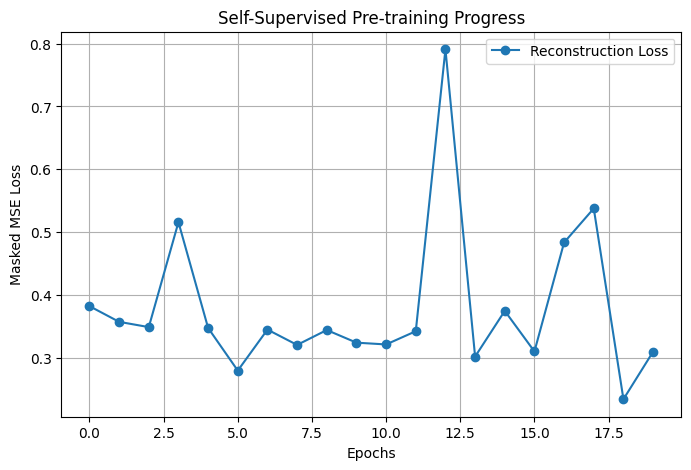

In [ ]:
bert_model, history= pretrain()
plot_loss(history)

In [ ]:
folder_path = "drive/MyDrive/Exoplanet Detection/"

In [ ]:
torch.save(bert_model.state_dict(),  folder_path + "models/ssl_model.ckpt")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

model = ExoBERT(d_model=128, heads=4, ff=256, layers=2).to(DEVICE)

Using cuda device


In [ ]:
model.load_state_dict(torch.load(folder_path + "models/ssl_model.ckpt"))

<All keys matched successfully>

In [ ]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

planet_class_id = 1

class TessH5Dataset(Dataset):
    def __init__(self, h5_path, augment=False):
        self.f = h5py.File(h5_path, "r")
        self.global_flux  = self.f["global_flux_view_fluxnorm"]
        self.global_centr = self.f["global_centr_view"]
        self.local_flux   = self.f["local_flux_view_fluxnorm"]
        self.local_centr  = self.f["local_centr_view"]
        self.labels       = self.f["label"]
        self.N = self.labels.shape[0]

        # Initialize augmenter if this is a training set
        self.augment = augment
        #self.augmenter = TimeSeriesAugmenter()

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        # Load raw data
        g_flux = self.global_flux[idx]
        g_cent = self.global_centr[idx]
        l_flux = self.local_flux[idx]
        l_cent = self.local_centr[idx]
        label  = self.labels[idx]

        sample = {
            "global_flux": torch.tensor(g_flux, dtype=torch.float32),
            "global_cent": torch.tensor(g_cent, dtype=torch.float32),
            "local_flux":  torch.tensor(l_flux, dtype=torch.float32),
            "local_cent":  torch.tensor(l_cent, dtype=torch.float32)
        }

        return sample, torch.tensor(label, dtype=torch.long)



planet_class_id = 1


train_ds = TessH5Dataset(folder_path + "tess_lightcurves_not_unk.h5")

labels = train_ds.labels[:]


N = len(labels)
all_indices = np.arange(N)

#stratified train split
train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels  # <--- KEY
)

#stratified val split
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

train_ds_split = Subset(train_ds, train_idx)
val_ds = Subset(train_ds, val_idx)
test_ds = Subset(train_ds, test_idx)

train_loader = DataLoader(train_ds_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)



In [ ]:
from sklearn.metrics import accuracy_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch.nn.functional as F
import torch
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(model, loader, device, pos_label=None):

    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds  = []
    all_pos_scores = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            for k in batch_x:
                batch_x[k] = batch_x[k].to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = F.cross_entropy(logits, batch_y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_labels.append(batch_y.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

            if pos_label is not None:
                all_pos_scores.append(probs[:, pos_label].cpu().numpy())

    # concatenate
    import numpy as np
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(y_true, y_pred)

    pr_auc = None
    if pos_label is not None:
        y_true_bin = (y_true == pos_label).astype(int)
        y_score = np.concatenate(all_pos_scores)
        pr_auc = average_precision_score(y_true_bin, y_score)


    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    """
    class_labels = ['NP', 'P'] # Not Planet, Planet

    # Generate the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot the confusion matrix
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for Transformer Model')
    plt.show()
    """
    return {
        "loss": avg_loss,
        "accuracy": acc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision,
        "f1": f1
    }


In [ ]:
def fine_tune(pretrained_bert_model):

    #get classifier
    clf_model = ExoClassifier(pretrained_bert_model).to(DEVICE)

    #freeze layers except head
    clf_model.freeze_encoder()

    ds = train_ds
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

    # don't include frozen params in optimizer
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, clf_model.parameters()), lr=LR_FINETUNE)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS_FINETUNE):
        clf_model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_x, batch_y in loader:
            for k in batch_x: batch_x[k] = batch_x[k].to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()
            logits = clf_model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

        epoch_loss = total_loss / len(loader)

            # ---- Validation at end of epoch ----
        val_metrics = evaluate(
            clf_model,
            val_loader,
            device=device,
            pos_label=planet_class_id,   # needed for PR-AUC
        )

        print(
            f"Epoch {epoch+1}/{EPOCHS_FINETUNE} | "
            f"epoch_loss={epoch_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_pr_auc={val_metrics['pr_auc']:.4f}"
        )

    """
    plt.figure(figsize=(8, 5))
    plt.plot(history, label="Reconstruction Loss", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Masked MSE Loss")
    plt.title("Self-Supervised Pre-training Progress")
    plt.legend()
    plt.grid(True)
    plt.savefig("pretrain_loss.png")
    print("\nLoss plot saved to 'pretrain_loss.png'")
    plt.show()
    """

    return clf_model

In [ ]:
fine_tuned_model = fine_tune(model)


--- Starting Fine-Tuning on Labeled Data ---
>> Encoder layers frozen.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/10 | epoch_loss=0.3360 | val_loss=0.2426 | val_acc=0.9354 | val_pr_auc=0.0967


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2/10 | epoch_loss=0.2311 | val_loss=0.2339 | val_acc=0.9354 | val_pr_auc=0.0991


...

Epoch 7/10 | epoch_loss=0.2157 | val_loss=0.2892 | val_acc=0.9354 | val_pr_auc=0.1117


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 8/10 | epoch_loss=0.2131 | val_loss=0.3156 | val_acc=0.9354 | val_pr_auc=0.1158


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 9/10 | epoch_loss=0.2115 | val_loss=0.3410 | val_acc=0.9354 | val_pr_auc=0.1203
Epoch 10/10 | epoch_loss=0.2100 | val_loss=0.3727 | val_acc=0.9242 | val_pr_auc=0.1259


In [ ]:
evaluate(fine_tuned_model,
        test_loader,
        device=device,
        pos_label=planet_class_id,   # needed for PR-AUC
    )

{'loss': 0.3714701632287965,
 'accuracy': 0.9252478134110788,
 'pr_auc': np.float64(0.1336997225349186),
 'recall': 0.010830324909747292,
 'precision': 0.06060606060606061,
 'f1': 0.018376722817764167}

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import numpy as np

fine_tuned_model.to(device)
fine_tuned_model.eval()

all_labels = []
all_logits = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        for k in batch_x:
            batch_x[k] = batch_x[k].to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)

        all_labels.append(batch_y.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

y_true = np.concatenate(all_labels)
all_logits_np = np.concatenate(all_logits)

num_classes = all_logits_np.shape[1]

In [ ]:
classes = {0: "Non-Planet", 1: "Planet"}

plt.figure(figsize=(8, 6))
ax = plt.gca()



for i in range(num_classes):
    # Convert true labels to binary for the current class
    y_true_bin = (y_true == i).astype(int)
    # Get scores for the current class (assuming logits are not yet softmaxed)
    y_score_class = all_logits_np[:, i]

    # Calculate PR-AUC for the current class
    pr_auc_score = average_precision_score(y_true_bin, y_score_class)
    print(f"Test Set PR-AUC for {classes[i]}: {pr_auc_score:.4f}")

    # Plot the Precision-Recall curve for the current class
    disp = PrecisionRecallDisplay.from_predictions(y_true_bin, y_score_class, name=f"{classes[i]} (PR-AUC={pr_auc_score:.4f})", ax=ax)

ax.set_title("Precision-Recall Curve Transformer")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
plt.legend(loc="lower left")
plt.savefig(folder_path + "/plots/pr_curve_transformer", dpi = 300)
plt.show()